In [30]:
import numpy as np
import matplotlib.pyplot as plt

CONSTANTS

In [31]:
T = 10 ** (-6)
f_0 = 10 ** 5
w_0 = 2 * np.pi * f_0
phi = np.pi / 8
A = 1
N = 513
n_0 = - (N - 1) / 2

P = (N * (N - 1)) / 2
Q = (N * (N - 1) * (2*N - 1)) / 6

SNR_db_list = np.array([-10, 0, 10, 20, 30, 40, 50, 60])
SNR_list = 10 ** (SNR_db_list / 20)
variance = A ** 2 / 2 * SNR_list
standard_deviation = np.sqrt(variance)

Generating instances

In [32]:
def x(t, standard_deviation):

    real_noise = np.random.normal(0, standard_deviation, t.shape)
    imaginary_noise = np.random.normal(0, standard_deviation, t.shape)

    complex_noise = real_noise + 1j * imaginary_noise

    return A * np.exp(1j * (w_0 * t + phi)) + complex_noise

Get m from the fft

In [33]:
def m(x, M): 
    return  np.max(np.fft(x,M))

Estimate radial frequency

In [34]:
def w_estimate(m, M):
    return (2 * np.pi * m) / (M * T)

Estimate phase

In [35]:
def F(w_estimate):

    sum = 0
    for n in range(n_0, n_0 + N, 1):
        sum += x(n*T) * np.exp(- 1j * w_estimate * n * T)

    F = sum / N

    return F

def phi_estimate(w_estimate):
    return np.angle(np.exp(- 1j * w_estimate * n_0 * T) * F(w_estimate))

Compute CRLB

In [36]:
def W_CRLB(standard_deviation):

    CRLB = (12 * standard_deviation**2) / (A**2 * T**2 * N * (N**2 - 1))

    return CRLB

def Phi_CRLB(standard_deviation):

    CRLB = (12 * standard_deviation**2 * (n_0**2 * N + 2 * n_0 * P + Q)) / (A**2 * N * (N**2 - 1))

    return CRLB

Simulate

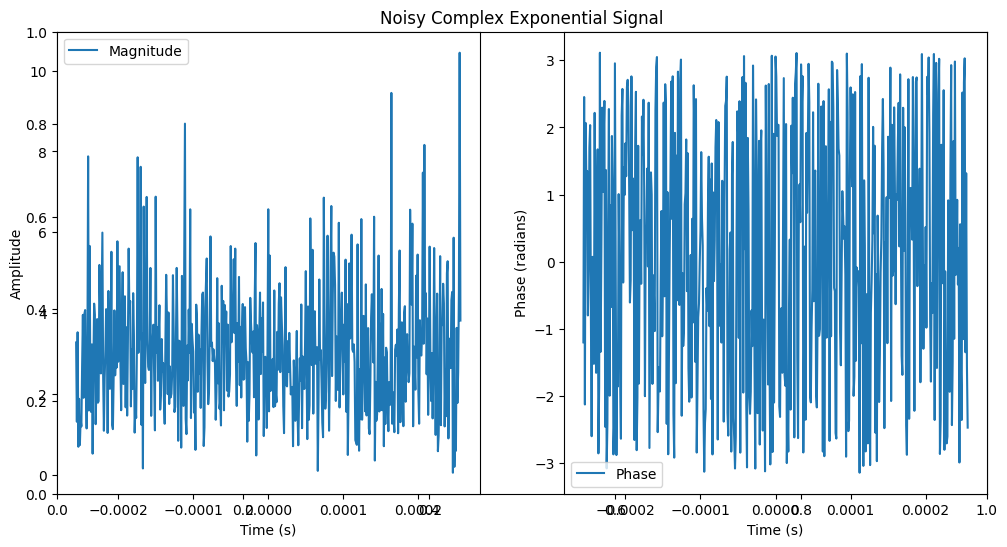

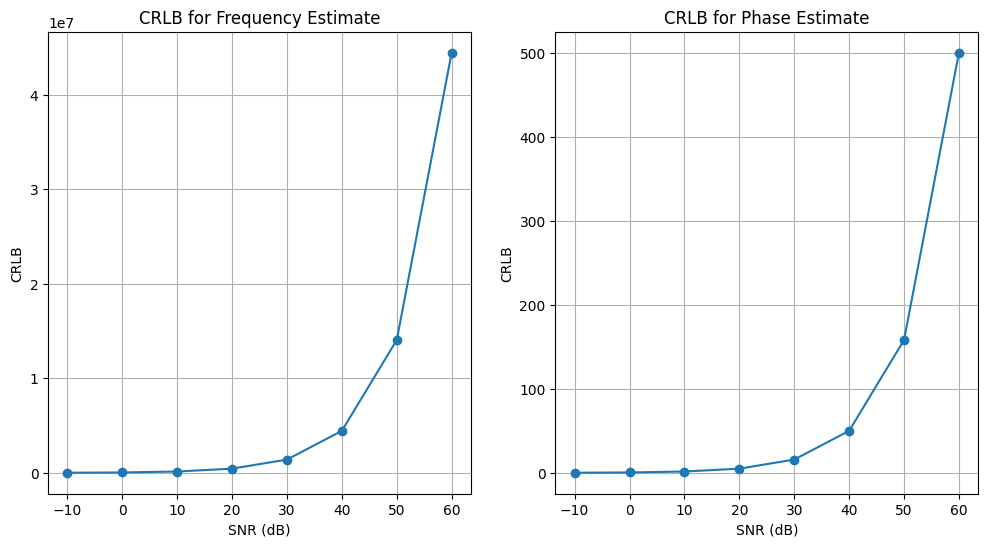

In [54]:
w_CRLB = W_CRLB(standard_deviation)
phi_CRLB = Phi_CRLB(standard_deviation)

t = np.arange(n_0, n_0 + N, 1) * T
x_values = x(t,standard_deviation[3])  # Example with SNR = 20 dB

plt.figure(figsize=(12, 6))
plt.title('Noisy Complex Exponential Signal')
plt.subplot(1, 2, 1)
plt.plot(t, np.absolute(x_values), label='Magnitude')
plt.xlabel('Time (s)')  
plt.ylabel('Amplitude')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t, np.angle(x_values), label='Phase')
plt.xlabel('Time (s)')
plt.ylabel('Phase (radians)')
plt.legend()


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(SNR_db_list, w_CRLB, marker='o')
plt.xlabel('SNR (dB)')
plt.ylabel('CRLB')
plt.title('CRLB for Frequency Estimate')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(SNR_db_list, phi_CRLB, marker='o')
plt.xlabel('SNR (dB)')
plt.ylabel('CRLB')
plt.title('CRLB for Phase Estimate')
plt.grid(True)